In [1]:
import pyhepmc as hep
import pandas as pd
import fastjet as fj
import numpy as np
import os
import gc
import psutil

# ---------------- Configurações ----------------
max_events = 1000000
chunk_size = 500

output_dir = "resultados_csv"
os.makedirs(output_dir, exist_ok=True)

sinal_files = [f'/home/lphelipe/Resultados/v3/pp_hh_{i}.hepmc' for i in range(1, 11)]
background_files = [
    '/home/lphelipe/Resultados/v3/pp_zz_1.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_2.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_3.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_4.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_5.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_6.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_7.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_8.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_9.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_10.hepmc',
    '/home/lphelipe/Resultados/v3/pp_hjj_2mu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jj.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jjmumu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_tt.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2b.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2mu.hepmc'
]

# ---------------- Funções utilitárias ----------------
def memory_usage_gb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1e9

def extract_cross_section(hepmc_file):
    with open(hepmc_file, 'r') as f:
        for line in f:
            if line.startswith('C'):
                try:
                    return float(line.split()[2])
                except:
                    return 0.0
    return 0.0

def remove_muons(particles):
    return [p for p in particles if abs(p.pid) != 13]

def find_opposite_charge_muons(particles):
    muons = [p for p in particles if abs(p.pid) == 13 and p.momentum.pt() > 20.0 and abs(p.momentum.eta()) < 2.5]
    muons_sorted = sorted(muons, key=lambda m: m.momentum.pt(), reverse=True)
    pairs = []
    used_indices = set()
    for i in range(len(muons_sorted)):
        if i in used_indices:
            continue
        for j in range(i+1, len(muons_sorted)):
            if j in used_indices:
                continue
            if muons_sorted[i].pid == -muons_sorted[j].pid:
                pairs.append((muons_sorted[i], muons_sorted[j]))
                used_indices.update([i, j])
                break
    return pairs

def invariant_mass(j1, j2):
    E = j1.e() + j2.e()
    px = j1.px() + j2.px()
    py = j1.py() + j2.py()
    pz = j1.pz() + j2.pz()
    m2 = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(m2) if m2 > 0 else 0.0

def delta_r(j1, j2):
    # cuidado com phi discontinuities
    dphi = j1.phi() - j2.phi()
    # normaliza dphi para [-pi, pi]
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    deta = j1.eta() - j2.eta()
    return np.sqrt(dphi**2 + deta**2)

# ---------------- Secondary Vertex b-tagger (realista) ----------------
def is_b_tagged_secondary_vertex_realistic(jet, event_particles, jet_cone=0.4):
    """
    Reconstrói candidatos a vértice secundário usando production_vertex das trilhas
    dentro do cone do jato, sem usar PDG (truth). Retorna:
    (is_b, Lxy, ntracks, mass)
    - is_b: bool (critério simples)
    - Lxy: deslocamento transverso do melhor candidato (unidade conforme o HepMC)
    - ntracks: número de trilhas no vértice
    - mass: massa invariante do conjunto de trilhas do vértice
    """
    jet_eta = jet.eta()
    jet_phi = jet.phi()

    # 1) Seleciona trilhas (status=1) do jato
    jet_tracks = []
    for p in event_particles:
        if getattr(p, "status", None) != 1:
            continue
        if p.production_vertex is None:
            continue
        # direção da partícula
        p_eta = p.momentum.eta()
        p_phi = p.momentum.phi()
        dphi = jet_phi - p_phi
        dphi = (dphi + np.pi) % (2*np.pi) - np.pi
        deta = jet_eta - p_eta
        dR = np.sqrt(dphi*dphi + deta*deta)
        if dR < jet_cone:
            jet_tracks.append(p)

    # precisa de pelo menos 2 trilhas para formar vértice
    if len(jet_tracks) < 2:
        return False, 0.0, 0, 0.0

    # 2) Agrupar trilhas pelo objeto production_vertex (assumimos que id(vtx) identifica o vértice)
    vertices = {}
    for trk in jet_tracks:
        vtx = trk.production_vertex
        if vtx is None:
            continue
        v_id = id(vtx)
        if v_id not in vertices:
            vertices[v_id] = {
                "vtx_obj": vtx,
                "tracks": []
            }
        vertices[v_id]["tracks"].append(trk)

    # 3) Construir candidatos a vértice secundário (descartar primário próximo de 0)
    secondary_candidates = []
    for v_id, info in vertices.items():
        v = info["vtx_obj"]
        # coordenadas do vértice (assumo unidade compatível; se for metros, ajuste limiares)
        x = getattr(v.position, "x", 0.0)
        y = getattr(v.position, "y", 0.0)
        z = getattr(v.position, "z", 0.0)
        Lxy = np.sqrt(x**2 + y**2)

        # Descartar vértices muito próximos ao primário (ex.: Lxy < 0.1 mm)
        # Ajuste esse cut conforme a unidade do seu HepMC (mm vs m).
        if Lxy < 0.1:
            continue

        # Massa invariante aproximada do conjunto de trilhas do vértice
        E = 0.0; px = 0.0; py = 0.0; pz = 0.0
        for trk in info["tracks"]:
            # Alguns objetos podem ter atributos diferentes; usar .momentum.x etc.
            E += getattr(trk.momentum, "e", 0.0)
            px += getattr(trk.momentum, "x", 0.0)
            py += getattr(trk.momentum, "y", 0.0)
            pz += getattr(trk.momentum, "z", 0.0)
        mass2 = E**2 - (px**2 + py**2 + pz**2)
        mass = np.sqrt(mass2) if mass2 > 0 else 0.0

        secondary_candidates.append({
            "Lxy": Lxy,
            "ntracks": len(info["tracks"]),
            "mass": mass,
            "tracks": info["tracks"]
        })

    if not secondary_candidates:
        return False, 0.0, 0, 0.0

    # 4) Seleciona o candidato com maior Lxy (típico em SV taggers)
    sv = max(secondary_candidates, key=lambda x: x["Lxy"])

    # 5) Critérios simples e realistas (ajuste conforme necessário)
    # - Lxy > 0.5 mm
    # - ntracks >= 2
    # - mass > 1.0 GeV
    # Se unidades do HepMC forem metros, converta ou ajuste cortes.
    is_b = (sv["Lxy"] > 0.5 and sv["ntracks"] >= 2 and sv["mass"] > 1.0)

    return is_b, sv["Lxy"], sv["ntracks"], sv["mass"]

# ---------------- Leitura de chunks com pesos ----------------
def read_hepmc_file_in_chunks_with_weights(hepmc_file, max_events=max_events):
    events = []
    weights = []
    with hep.open(hepmc_file) as f:
        for i, event in enumerate(f):
            if i >= max_events:
                break
            events.append(event)
            # safety: se event.weights estiver vazio, usa 1.0
            w = event.weights[-1] if getattr(event, "weights", None) and len(event.weights) > 0 else 1.0
            weights.append(w)
            if (i+1) % chunk_size == 0:
                print(f"{i+1} eventos lidos do arquivo {os.path.basename(hepmc_file)} / mem: {memory_usage_gb():.2f} Gb")
                yield events, np.array(weights)
                events = []
                weights = []
                gc.collect()
        if events:
            print(f"{i+1} eventos lidos do arquivo {os.path.basename(hepmc_file)} (último chunk) / mem: {memory_usage_gb():.2f} Gb")
            yield events, np.array(weights)

# ---------------- Extração de informações do evento (com SV b-tagging) ----------------
def extract_event_info(events, weights=None, cross_section=0.0):
    data = []
    for i, event in enumerate(events):
        # Seleciona partículas estáveis com pT > 2 GeV
        particles = [p for p in event.particles if getattr(p, "status", None) == 1 and p.momentum.pt() > 2.0]
        muon_pairs = find_opposite_charge_muons(particles)
        if not muon_pairs:
            continue
        mu1, mu2 = muon_pairs[0]
        m1 = fj.PseudoJet(mu1.momentum.x, mu1.momentum.y, mu1.momentum.z, mu1.momentum.e)
        m2 = fj.PseudoJet(mu2.momentum.x, mu2.momentum.y, mu2.momentum.z, mu2.momentum.e)
        inv_mass_muons = invariant_mass(m1, m2)
        if not (100 < inv_mass_muons < 150):
            continue

        # remove múons para reconstrução de jatos
        particles_no_muons = remove_muons(particles)
        # converter para fastjet PseudoJet
        fj_particles = [fj.PseudoJet(p.momentum.x, p.momentum.y, p.momentum.z, p.momentum.e) for p in particles_no_muons]

        # clusterização anti-kt R=0.4 e seleção de jatos com pT>30, |eta|<4.5
        jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
        cs = fj.ClusterSequence(fj_particles, jet_def)
        jets = [j for j in cs.inclusive_jets(30.0) if abs(j.eta()) < 4.5]

        if len(jets) < 2:
            continue

        # pega os dois leading jets
        jet1, jet2 = sorted(jets, key=lambda j: j.pt(), reverse=True)[:2]
        dijet_mass = invariant_mass(jet1, jet2)
        if not (100 <= dijet_mass <= 125):
            continue

        # massa di-Higgs (2 múons + 2 jatos)
        dihiggs_E = m1.e() + m2.e() + jet1.e() + jet2.e()
        dihiggs_px = m1.px() + m2.px() + jet1.px() + jet2.px()
        dihiggs_py = m1.py() + m2.py() + jet1.py() + jet2.py()
        dihiggs_pz = m1.pz() + m2.pz() + jet1.pz() + jet2.pz()
        dihiggs_mass = np.sqrt(max(dihiggs_E**2 - (dihiggs_px**2 + dihiggs_py**2 + dihiggs_pz**2), 0))

        # -------- b-tagging por Vértice Secundário (realista) -----------
        is_b1, Lxy1, ntrk1, mass1 = is_b_tagged_secondary_vertex_realistic(jet1, particles_no_muons)
        is_b2, Lxy2, ntrk2, mass2 = is_b_tagged_secondary_vertex_realistic(jet2, particles_no_muons)

        # monta dicionário do evento
        event_info = {
            'muon_mass': inv_mass_muons,
            'muon1_pt': m1.pt(),
            'muon2_pt': m2.pt(),
            'muon1_eta': m1.eta(),
            'muon2_eta': m2.eta(),
            'dimuon_eta': 0.5*(m1.eta()+m2.eta()),
            'dimuon_pt': m1.pt()+m2.pt(),
            'dimuon_energy': m1.e()+m2.e(),
            'dijet_mass': dijet_mass,
            'dihiggs_mass': dihiggs_mass,
            'jet1_pt': jet1.pt(),
            'jet2_pt': jet2.pt(),
            'jet1_eta': jet1.eta(),
            'jet2_eta': jet2.eta(),
            'di_jet_eta': 0.5*(jet1.eta()+jet2.eta()),
            'di_jet_pt': jet1.pt()+jet2.pt(),
            'di_jet_energy': jet1.e()+jet2.e(),
            'delta_r': delta_r(jet1, jet2),
            'num_jets': len(jets),

            # ---- campos de b-tagging (SV realistic) ----
            'jet1_is_b_tagged': is_b1,
            'jet2_is_b_tagged': is_b2,
            'jet1_sv_Lxy': Lxy1,
            'jet2_sv_Lxy': Lxy2,
            'jet1_sv_ntracks': ntrk1,
            'jet2_sv_ntracks': ntrk2,
            'jet1_sv_mass': mass1,
            'jet2_sv_mass': mass2,

            # pesos e xsec
            'weight': weights[i] if weights is not None and i < len(weights) else 1.0,
            'cross_section_pb': cross_section
        }
        data.append(event_info)
    if data:
        return pd.DataFrame(data)
    else:
        return pd.DataFrame(columns=[
            'muon_mass','muon1_pt','muon2_pt','muon1_eta','muon2_eta','dimuon_eta','dimuon_pt','dimuon_energy',
            'dijet_mass','dihiggs_mass','jet1_pt','jet2_pt','jet1_eta','jet2_eta','di_jet_eta','di_jet_pt','di_jet_energy',
            'delta_r','num_jets','jet1_is_b_tagged','jet2_is_b_tagged','jet1_sv_Lxy','jet2_sv_Lxy','jet1_sv_ntracks','jet2_sv_ntracks','jet1_sv_mass','jet2_sv_mass','weight','cross_section_pb'
        ])

# ---------------- Processamento de arquivos ----------------
def process_files(file_list, label):
    all_dfs = []
    for f in file_list:
        cs = extract_cross_section(f)
        for chunk, weights in read_hepmc_file_in_chunks_with_weights(f):
            df_chunk = extract_event_info(chunk, weights, cross_section=cs)
            if df_chunk.empty:
                continue
            df_chunk['label'] = label
            all_dfs.append(df_chunk)
    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()

# ---------------- Rodar a análise ----------------
if __name__ == "__main__":
    signal_df = process_files(sinal_files, label=1)
    signal_df.to_csv(os.path.join(output_dir, "signal_raw_v5_sv.csv"), index=False)

    background_df = process_files(background_files, label=0)
    background_df.to_csv(os.path.join(output_dir, "background_raw_v5_sv.csv"), index=False)

    combined_df = pd.concat([signal_df, background_df], ignore_index=True) if (not signal_df.empty or not background_df.empty) else pd.DataFrame()
    if not combined_df.empty:
        combined_df.to_csv(os.path.join(output_dir, "all_events_raw_v5_sv.csv"), index=False)
        print(f">> Arquivos de eventos salvos em {output_dir}")
    else:
        print(">> Nenhum evento selecionado para salvar.")

    # ---------------- Salvar metadados (cross sections) ----------------
    metadata = []
    for f in sinal_files + background_files:
        metadata.append({"file": os.path.basename(f), "cross_section_pb": extract_cross_section(f)})

    pd.DataFrame(metadata).to_csv(os.path.join(output_dir, "cross_sections_v5_sv.csv"), index=False)
    print(f">> Arquivo 'cross_sections_v4_sv.csv' salvo em {output_dir}")


500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 0.90 Gb
#--------------------------------------------------------------------------
#                         FastJet release 3.4.2
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
1000 eventos 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



493000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
493500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
494000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
494500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
495000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
495500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
496000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
496500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
497000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
497500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
498000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
498500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
499000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
499500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
500000 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 1.99 Gb
500500 eventos lidos do arquivo pp_jjmumu.hepmc / mem: 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



681500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
682000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
682500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
683000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
683500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
684000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
684500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
685000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
685500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
686000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
686500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
687000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
687500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
688000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
688500 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 2.06 Gb
689000 eventos lidos do arquivo pp_zjj_2b.hepmc / mem: 

In [2]:
import pandas as pd
import numpy as np
import os

# ---------------- Configurações ----------------
TARGET_LUMINOSITY = 20000  # em fb^-1 
input_file = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"
output_file = "/home/lphelipe/Cuts_code/resultados_csv/all_events_normalized_v5.csv"

# ---------------- Função de Normalização ----------------
def normalize_weights(weights, cross_section, luminosity=TARGET_LUMINOSITY, efficiency=1.0):
    """
    Normaliza pesos de Monte Carlo com base na seção de choque.
    - Mantém a coluna 'weight' (substitui valores).
    - Se soma(weights) == 0, faz fallback usando soma(|weights|).
    Retorna os pesos normalizados e a soma.
    """
    expected_sum = cross_section * 1e3 * luminosity
    sum_w = np.sum(weights)
    sum_abs = np.sum(np.abs(weights))

    if sum_abs <= 0 or efficiency <= 0:
        return np.zeros_like(weights), 0.0
    """
    if np.isclose(sum_w, 0.0):
        norm_factor = expected_sum / sum_abs
        normalized = weights * norm_factor
        actual_sum = np.sum(normalized)
        print(f"AVISO: soma dos pesos originais ≈ 0 para σ={cross_section} pb. Usando soma(|weights|). Σpesos_normalizados={actual_sum:.1f} (esperado={expected_sum:.1f})")
        return normalized, actual_sum
     """   

    norm_factor = expected_sum / sum_w
    normalized = weights * norm_factor
    actual_sum = np.sum(normalized)
    print(f"Verificação: σ={cross_section} pb → Σpesos_normalizados={actual_sum:.1f} (esperado={expected_sum:.1f})")
    return normalized, actual_sum

# ---------------- Processamento ----------------
print(">> Lendo CSV bruto...")
df = pd.read_csv(input_file)

df["weight"] = df["weight"].astype(float)

# Criar coluna para armazenar a soma dos pesos
df["sum_weights"] = 0.0

# Normalizar e sobrescrever IN-PLACE na coluna 'weight'
for cross_section, group in df.groupby("cross_section_pb"):
    idx = group.index
    print(f"\n>> Normalizando grupo com σ = {cross_section} pb, eventos = {len(group)}")
    weights = df.loc[idx, "weight"].to_numpy()
    normalized, sum_norm = normalize_weights(weights, cross_section)
    df.loc[idx, "weight"] = normalized
    df.loc[idx, "sum_weights"] = sum_norm  # mesma soma em todas as linhas do grupo

# salvar
df.to_csv(output_file, index=False)
print(f"\n>> Arquivo normalizado salvo em: {output_file}")


>> Lendo CSV bruto...

>> Normalizando grupo com σ = 0.00019517858 pb, eventos = 8501
Verificação: σ=0.00019517858 pb → Σpesos_normalizados=3903.6 (esperado=3903.6)

>> Normalizando grupo com σ = 0.00019525615 pb, eventos = 8620
Verificação: σ=0.00019525615 pb → Σpesos_normalizados=3905.1 (esperado=3905.1)

>> Normalizando grupo com σ = 0.00019537009 pb, eventos = 8612
Verificação: σ=0.00019537009 pb → Σpesos_normalizados=3907.4 (esperado=3907.4)

>> Normalizando grupo com σ = 0.00019538221 pb, eventos = 8771
Verificação: σ=0.00019538221 pb → Σpesos_normalizados=3907.6 (esperado=3907.6)

>> Normalizando grupo com σ = 0.00019543312 pb, eventos = 8702
Verificação: σ=0.00019543312 pb → Σpesos_normalizados=3908.7 (esperado=3908.7)

>> Normalizando grupo com σ = 0.00019546949 pb, eventos = 8777
Verificação: σ=0.00019546949 pb → Σpesos_normalizados=3909.4 (esperado=3909.4)

>> Normalizando grupo com σ = 0.00019547433 pb, eventos = 8700
Verificação: σ=0.00019547433 pb → Σpesos_normalizados=39

In [3]:
import pandas as pd
import numpy as np

csv_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"

df = pd.read_csv(csv_path)

# Extrair valores únicos
xsecs = df["cross_section_pb"].unique()

# Ordenar
xsecs_sorted = np.sort(xsecs)

print("\n====== LISTA COMPLETA DE CROSS SECTIONS ÚNICAS ======\n")
for x in xsecs_sorted:
    print(repr(x))  # repr() mantém TODAS as casas decimais exatas



====== LISTA COMPLETA DE CROSS SECTIONS ÚNICAS ======

np.float64(0.00019517858)
np.float64(0.00019525615)
np.float64(0.00019537009)
np.float64(0.00019538221)
np.float64(0.00019543312)
np.float64(0.00019546949)
np.float64(0.00019547433)
np.float64(0.00019548161)
np.float64(0.00019551555)
np.float64(0.0066212769)
np.float64(0.4151427)
np.float64(0.41524018)
np.float64(0.41527337)
np.float64(0.41538952)
np.float64(0.4154704)
np.float64(0.41553159)
np.float64(0.41555751)
np.float64(0.41561455)
np.float64(0.41576596)
np.float64(0.4158188500000001)
np.float64(1393.5323)
np.float64(2987.982200000001)
np.float64(24669.015000000007)


In [12]:
import pandas as pd

# Caminho do CSV
csv_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"

# Luminosidade
L = 30000  # fb^-1


# ============================================================
# Você define quantos eventos foram gerados de cada processo
# ============================================================
N_events_dict = {
    "pp_hh": 1_000_000,
    "pp_zz": 1_000_000,
    "pp_hjj_2mu": 1_000_000,
    "pp_jj": 1_000_000,
    "pp_jjmumu": 1_000_000,
    "pp_tt": 1_000_000,
    "pp_zjj_2b": 1_000_000,
    "pp_zjj_2mu": 1_000_000,
}


# ============================================================
# Cross sections de TODOS os processos
# ============================================================

# 10 arquivos pp_zz
pzz_cross_sections = [
    0.4151427,
    0.41524018,
    0.41527337,
    0.41538952,
    0.4154704,
    0.41553159,
    0.41555751,
    0.41561455,
    0.41576596,
    0.41581885,
    0.4158188500000001
]

# 10 arquivos pp_hh
phh_cross_sections = [
    0.00019551555000000003,
    0.00019548161,
    0.00019537009,
    0.00019546949,
    0.00019551555,
    0.00019547433,
    0.00019517858,
    0.00019538221,
    0.00019525615,
    0.00019543312
]

# Processos únicos
single_xsecs = {
    0.0066212769: "pp_hjj_2mu",
    7621929600.000001:     "pp_jj",
    1393.5323:             "pp_jjmumu",
    24669.015000000007:    "pp_tt",
    13098.517:             "pp_zjj_2b",
    2987.982200000001:     "pp_zjj_2mu",
}


# ============================================================
# Criar dicionário de cross section → processo
# ============================================================

cross_section_match = {}

for x in pzz_cross_sections:
    cross_section_match[x] = "pp_zz"

for x in phh_cross_sections:
    cross_section_match[x] = "pp_hh"

for xsec, name in single_xsecs.items():
    cross_section_match[xsec] = name


# ============================================================
# Carregar CSV
# ============================================================

df = pd.read_csv(csv_path)


# ============================================================
# Calcular os pesos
# ============================================================

weights = []
process_names = []

for _, row in df.iterrows():
    xsec = row["cross_section_pb"]

    if xsec not in cross_section_match:
        print(f"⚠ A cross section {xsec} não corresponde a nenhum processo conhecido.")
        weights.append(0)
        process_names.append("UNKNOWN")
        continue

    process = cross_section_match[xsec]
    process_names.append(process)

    N = N_events_dict[process]
    w = (xsec * L) / N
    weights.append(w)

df["process"] = process_names
df["weight"] = weights


# ============================================================
# Salvar resultado
# ============================================================

output = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weighted.csv"
df.to_csv(output, index=False)

print("Arquivo salvo:", output)


Arquivo salvo: /home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weighted.csv


In [21]:
import pandas as pd

# Caminho do seu CSV SEM pesos
csv_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"

# Luminosidade
L = 30000000  # pb^-1

# ============================================================
# Eventos gerados de cada processo
# ============================================================
N_events_dict = {
    "pp_hh": 1_000_000,
    "pp_zz": 1_000_000,
    "pp_hjj_2mu": 1_000_000,
    "pp_jj": 1_000_000,
    "pp_jjmumu": 1_000_000,
    "pp_tt": 1_000_000,
    "pp_zjj_2b": 1_000_000,
    "pp_zjj_2mu": 1_000_000,
}

# ============================================================
# Cross sections
# ============================================================

pzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885,
    0.4158188500000001
]

phh_cross_sections = [
    0.00019551555000000003, 0.00019548161, 0.00019537009,
    0.00019546949, 0.00019551555, 0.00019547433,
    0.00019517858, 0.00019538221, 0.00019525615, 0.00019543312
]

single_xsecs = {
    0.0066212769: "pp_hjj_2mu",
    7621929600.000001: "pp_jj",
    1393.5323: "pp_jjmumu",
    24669.015000000007: "pp_tt",
    13098.517: "pp_zjj_2b",
    2987.982200000001: "pp_zjj_2mu",
}

# ============================================================
# Criar dicionário cross section → processo
# ============================================================
cross_section_match = {}

for x in pzz_cross_sections:
    cross_section_match[x] = "pp_zz"

for x in phh_cross_sections:
    cross_section_match[x] = "pp_hh"

for xsec, name in single_xsecs.items():
    cross_section_match[xsec] = name

# ============================================================
# Ler o CSV
# ============================================================
df = pd.read_csv(csv_path)

# ============================================================
# Calcular pesos e somas
# ============================================================
df["process"] = df["cross_section_pb"].map(cross_section_match)

df["weight"] = df.apply(
    lambda r: (r["cross_section_pb"] * L) / N_events_dict[r["process"]]
    if r["process"] in N_events_dict else 0,
    axis=1
)

# ============================================================
# Calcular sum_weights POR PROCESSO
# ============================================================
sum_w = df.groupby("process")["weight"].sum()

# ============================================================
# Mostrar resultados
# ============================================================
print("\n==============================")
print("      SUM_WEIGHTS POR PROCESSO")
print("==============================\n")

for proc, sw in sum_w.items():
    if proc is None:
        continue

    # cross section de referência
    xsec = df.loc[df["process"] == proc, "cross_section_pb"].iloc[0]
    N = N_events_dict[proc]
    weight_value = (xsec * L) / N  # peso de cada evento

    expected = xsec * L

    print(f"Processo: {proc}")
    print(f"  Cross section (pb): {xsec}")
    print(f"  Eventos gerados: {N}")
    print(f"  Peso por evento: {weight_value}")
    print(f"  expected_events = xsec * L = {expected}")
    print(f"  sum_weights calculado = {sw}")
    print(f"  Razão (sum_weights / expected) = {sw / expected}")
    print("-" * 60)

print("\n==============")
print("sum_weights TOTAL =", df["weight"].sum())
print("==============")



      SUM_WEIGHTS POR PROCESSO

Processo: pp_hh
  Cross section (pb): 0.00019551555
  Eventos gerados: 1000000
  Peso por evento: 0.0058654664999999995
  expected_events = xsec * L = 5865.4664999999995
  sum_weights calculado = 508.99020216959997
  Razão (sum_weights / expected) = 0.08677744594903065
------------------------------------------------------------
Processo: pp_hjj_2mu
  Cross section (pb): 0.0066212769
  Eventos gerados: 1000000
  Peso por evento: 0.19863830700000001
  expected_events = xsec * L = 198638.307
  sum_weights calculado = 2419.8118558740002
  Razão (sum_weights / expected) = 0.012182000000000002
------------------------------------------------------------
Processo: pp_jjmumu
  Cross section (pb): 1393.5323
  Eventos gerados: 1000000
  Peso por evento: 41805.969
  expected_events = xsec * L = 41805969000.0
  sum_weights calculado = 70024998.07499999
  Razão (sum_weights / expected) = 0.0016749999999999996
--------------------------------------------------------

In [23]:
import pandas as pd

# Caminho do CSV reduzido (após cortes)
csv_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"

# Luminosidade
L = 30000000  # pb^-1


# ============================================================
# Número TOTAL de eventos GERADOS (não os do CSV)
# ============================================================
N_events_dict = {
    "pp_hh": 1_000_000,
    "pp_zz": 1_000_000,
    "pp_hjj_2mu": 1_000_000,
    "pp_jj": 1_000_000,
    "pp_jjmumu": 1_000_000,
    "pp_tt": 1_000_000,
    "pp_zjj_2b": 1_000_000,
    "pp_zjj_2mu": 1_000_000,
}

# ============================================================
# Cross sections dos processos
# ============================================================

pzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885,
    0.4158188500000001
]

phh_cross_sections = [
    0.00019551555000000003, 0.00019548161, 0.00019537009,
    0.00019546949, 0.00019551555, 0.00019547433,
    0.00019517858, 0.00019538221, 0.00019525615, 0.00019543312
]

single_xsecs = {
    0.0066212769: "pp_hjj_2mu",
    7621929600.000001: "pp_jj",
    1393.5323: "pp_jjmumu",
    24669.015000000007: "pp_tt",
    13098.517: "pp_zjj_2b",
    2987.982200000001: "pp_zjj_2mu",
}


# ============================================================
# Dicionário cross_section → processo
# ============================================================
cross_section_match = {}

for x in pzz_cross_sections:
    cross_section_match[x] = "pp_zz"

for x in phh_cross_sections:
    cross_section_match[x] = "pp_hh"

for xsec, name in single_xsecs.items():
    cross_section_match[xsec] = name


# ============================================================
# Ler o CSV reduzido
# ============================================================
df = pd.read_csv(csv_path)
df["process"] = df["cross_section_pb"].map(cross_section_match)

# ============================================================
# Calcular peso TEÓRICO (usando eventos gerados)
# ============================================================
df["weight"] = df.apply(
    lambda r: (r["cross_section_pb"] * L) / N_events_dict[r["process"]]
    if r["process"] in N_events_dict else 0,
    axis=1
)


# ============================================================
# Análise por processo
# ============================================================
print("\n==============================")
print("      SUM_WEIGHTS POR PROCESSO")
print("==============================\n")

for process in df["process"].unique():

    df_proc = df[df["process"] == process]

    xsec = df_proc["cross_section_pb"].iloc[0]
    N_generated = N_events_dict[process]
    N_after_cut = len(df_proc)

    weight_value = (xsec * L) / N_generated
    expected_events = xsec * L
    sum_weights = df_proc["weight"].sum()

    efficiency = N_after_cut / N_generated

    print(f"Processo: {process}")
    print(f"  Cross section (pb): {xsec}")
    print(f"  Eventos gerados (MC): {N_generated}")
    print(f"  Eventos no CSV (após cortes): {N_after_cut}")
    print(f"  Eficiência dos cortes: {efficiency:.6f}")
    print(f"  Peso por evento: {weight_value}")
    print(f"  expected_events = xsec * L = {expected_events}")
    print(f"  sum_weights calculado = {sum_weights}")
    print(f"  Razão (sum_weights / expected) = {sum_weights / expected_events}")
    print("-" * 60)



      SUM_WEIGHTS POR PROCESSO

Processo: pp_hh
  Cross section (pb): 0.00019551555
  Eventos gerados (MC): 1000000
  Eventos no CSV (após cortes): 86825
  Eficiência dos cortes: 0.086825
  Peso por evento: 0.0058654664999999995
  expected_events = xsec * L = 5865.4664999999995
  sum_weights calculado = 508.9902021696
  Razão (sum_weights / expected) = 0.08677744594903067
------------------------------------------------------------
Processo: pp_zz
  Cross section (pb): 0.41527337
  Eventos gerados (MC): 1000000
  Eventos no CSV (após cortes): 63
  Eficiência dos cortes: 0.000063
  Peso por evento: 12.4582011
  expected_events = xsec * L = 12458201.1
  sum_weights calculado = 785.2748097
  Razão (sum_weights / expected) = 6.303276078116928e-05
------------------------------------------------------------
Processo: pp_hjj_2mu
  Cross section (pb): 0.0066212769
  Eventos gerados (MC): 1000000
  Eventos no CSV (após cortes): 12182
  Eficiência dos cortes: 0.012182
  Peso por evento: 0.1986

In [24]:
import pandas as pd

# Caminho do CSV reduzido (após cortes)
csv_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv.csv"

# Luminosidade
L = 30000000  # pb^-1


# ============================================================
# Número TOTAL de eventos GERADOS (não os do CSV)
# ============================================================
N_events_dict = {
    "pp_hh": 1_000_000,
    "pp_zz": 1_000_000,
    "pp_hjj_2mu": 1_000_000,
    "pp_jj": 1_000_000,
    "pp_jjmumu": 1_000_000,
    "pp_tt": 1_000_000,
    "pp_zjj_2b": 1_000_000,
    "pp_zjj_2mu": 1_000_000,
}

# ============================================================
# Cross sections dos processos
# ============================================================
pzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885,
    0.4158188500000001
]

phh_cross_sections = [
    0.00019551555000000003, 0.00019548161, 0.00019537009,
    0.00019546949, 0.00019551555, 0.00019547433,
    0.00019517858, 0.00019538221, 0.00019525615, 0.00019543312
]

single_xsecs = {
    0.0066212769: "pp_hjj_2mu",
    7621929600.000001: "pp_jj",
    1393.5323: "pp_jjmumu",
    24669.015000000007: "pp_tt",
    13098.517: "pp_zjj_2b",
    2987.982200000001: "pp_zjj_2mu",
}

# ============================================================
# Dicionário cross_section → processo
# ============================================================
cross_section_match = {}

for x in pzz_cross_sections:
    cross_section_match[x] = "pp_zz"

for x in phh_cross_sections:
    cross_section_match[x] = "pp_hh"

for xsec, name in single_xsecs.items():
    cross_section_match[xsec] = name


# ============================================================
# Ler o CSV original
# ============================================================
df = pd.read_csv(csv_path)
df["process"] = df["cross_section_pb"].map(cross_section_match)

# ============================================================
# Calcular pesos por evento
# ============================================================
df["weight"] = df.apply(
    lambda r: (r["cross_section_pb"] * L) / N_events_dict[r["process"]]
    if r["process"] in N_events_dict else 0,
    axis=1
)

# ============================================================
# Calcular sum_weights por processo
# ============================================================
sumW_dict = df.groupby("process")["weight"].sum().to_dict()

# Criar coluna sum_weights repetindo o valor para todos os eventos do processo
df["sum_weights"] = df["process"].map(sumW_dict)

# ============================================================
# Salvar o CSV completo
# ============================================================
output_path = "/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weight.csv"
df.to_csv(output_path, index=False)

print(f"\nArquivo final salvo em:\n{output_path}")
print("\nColunas adicionadas: weight, sum_weights\n")



Arquivo final salvo em:
/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weight.csv

Colunas adicionadas: weight, sum_weights



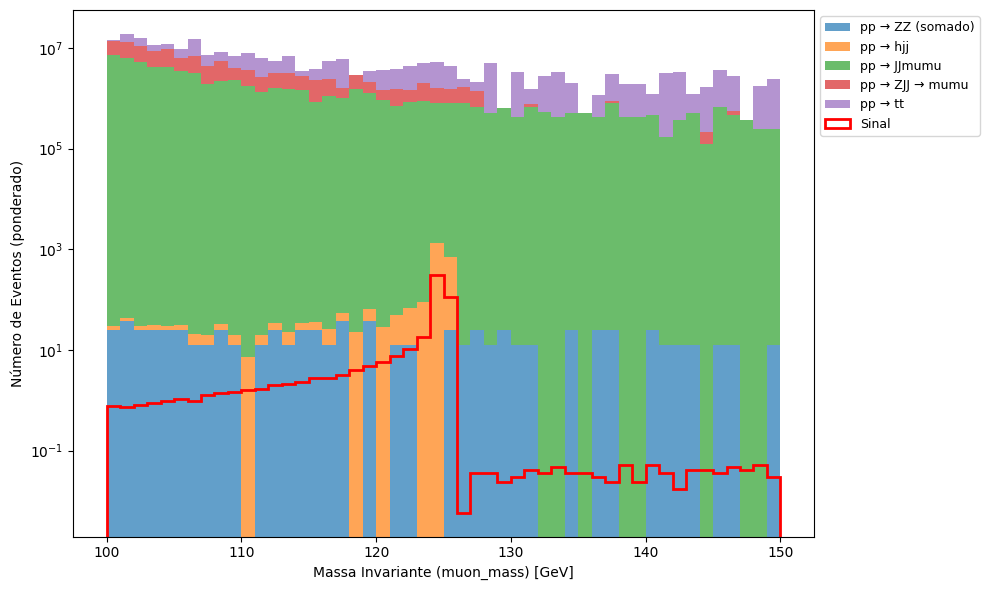

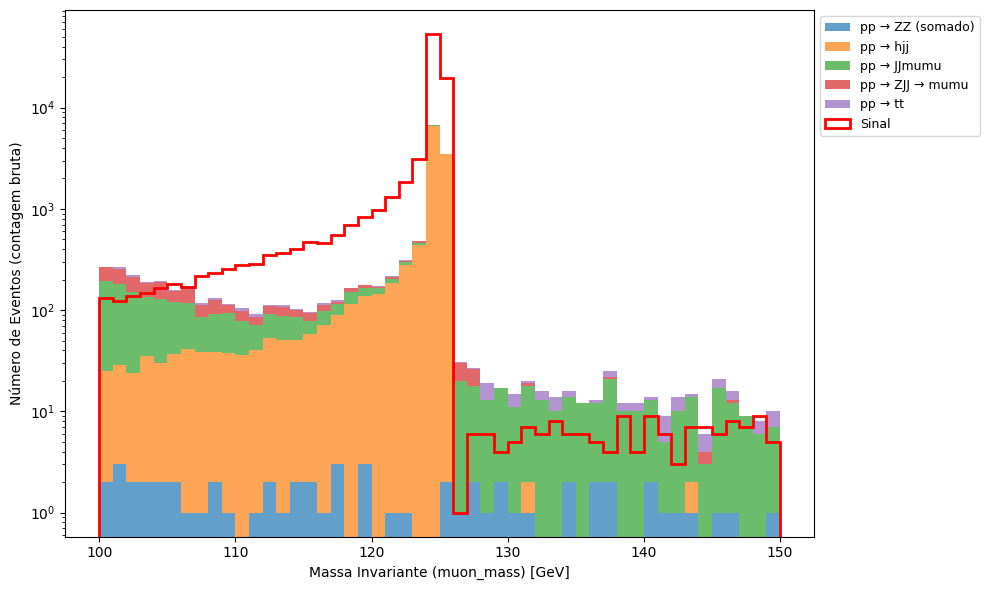

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weight.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['muon_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue  # <-- remove completamente o background desconhecido

    bkg_datasets.append(group['muon_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 150), weights=bkg_weights,
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['muon_mass'], bins=50, range=(100, 150),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('Massa Invariante (muon_mass) [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de dimuons (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/massa_muons_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 150), stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['muon_mass'], bins=50, range=(100, 150),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('Massa Invariante (muon_mass) [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de dimuons (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/massa_muons_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


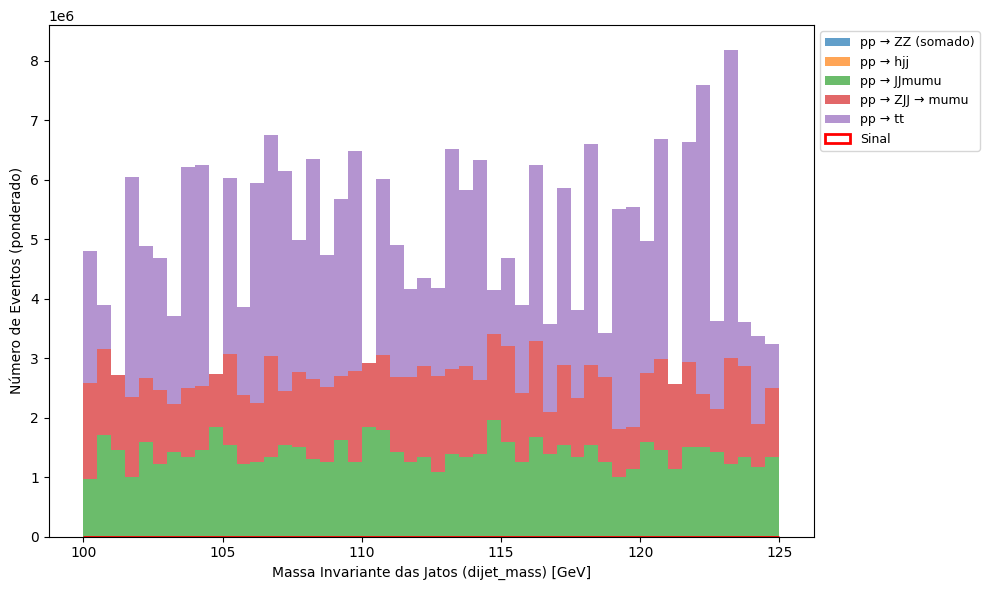

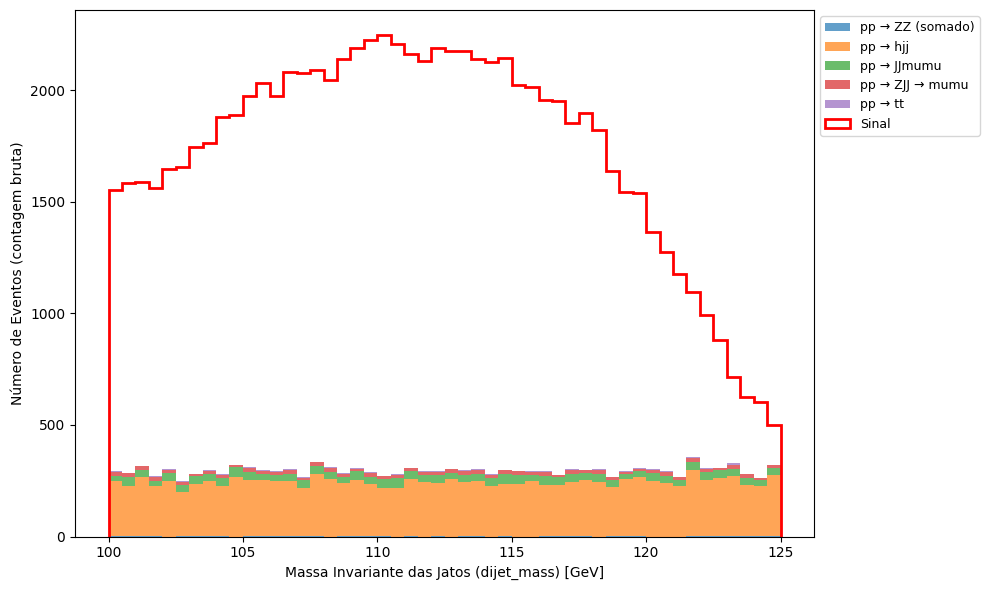

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weight.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['dijet_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['dijet_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 125),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['dijet_mass'], bins=50, range=(100, 125),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('Massa Invariante das Jatos (dijet_mass) [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 125),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['dijet_mass'], bins=50, range=(100, 125),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('Massa Invariante das Jatos (dijet_mass) [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


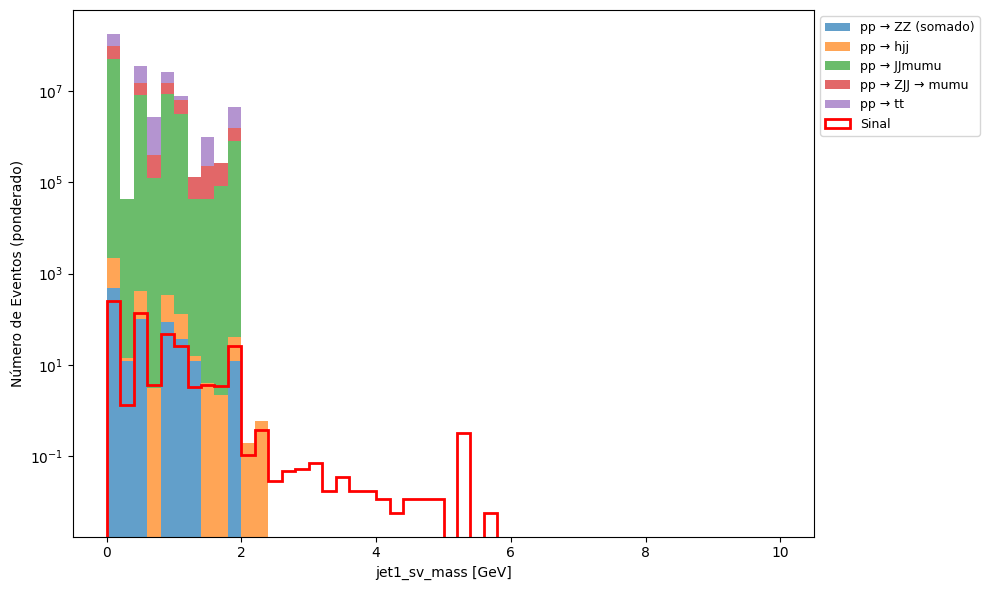

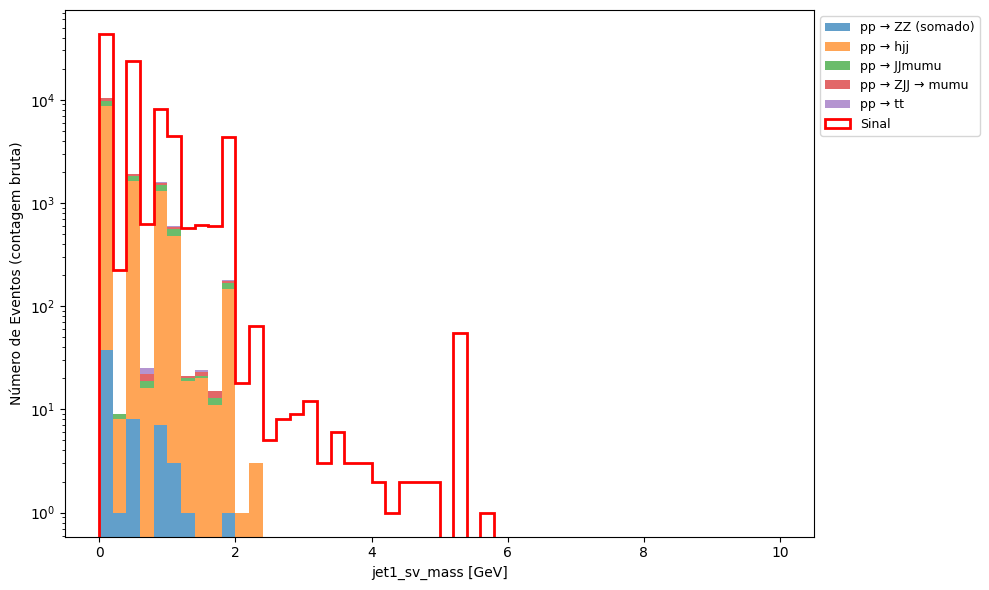

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weight.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_mass'], bins=50, range=(0, 10),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_mass [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_mass'], bins=50, range=(0, 10),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_mass [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


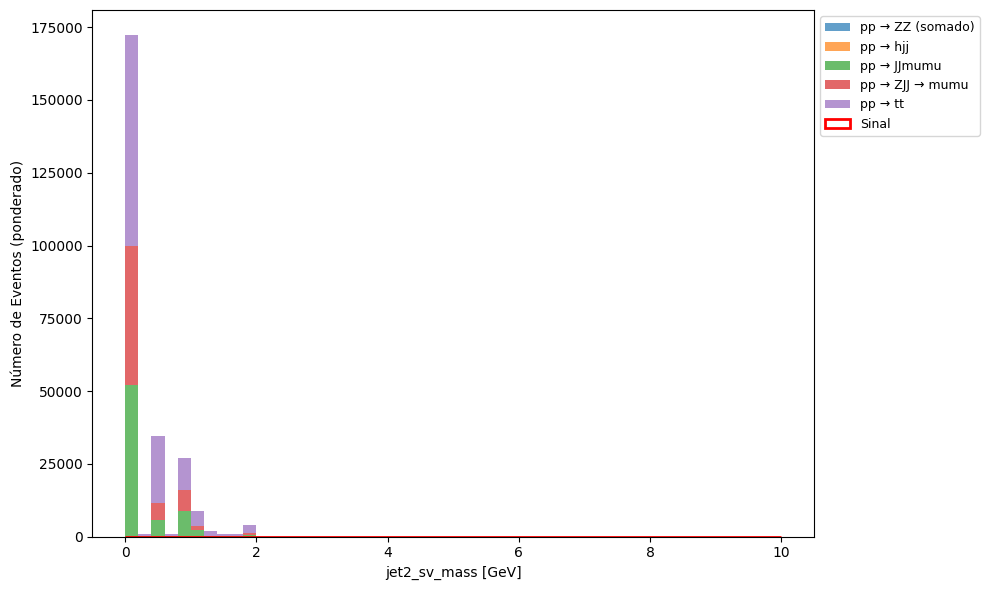

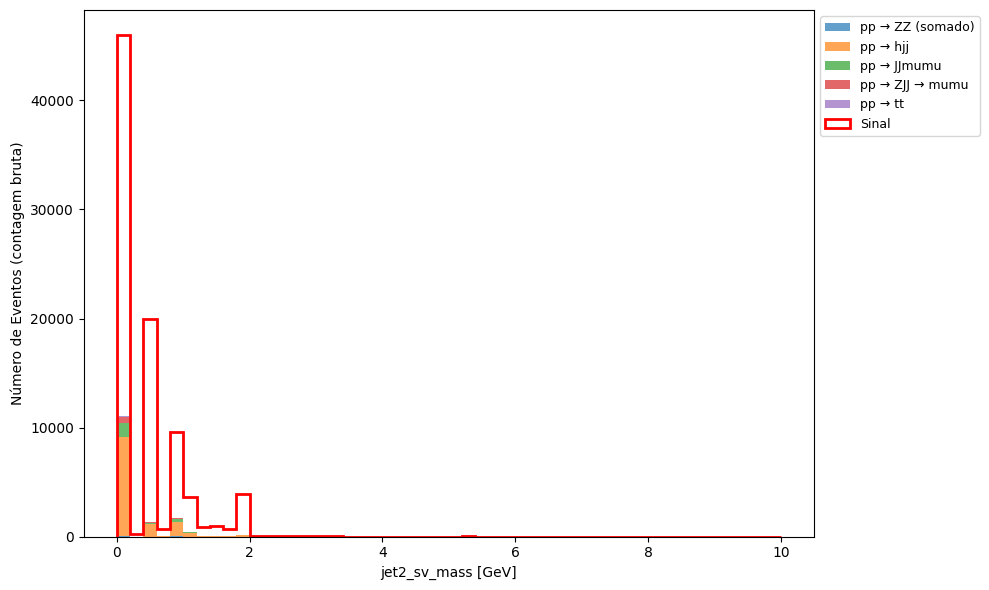

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weighted.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet2_sv_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_mass'], bins=50, range=(0, 10),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_mass [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_mass'], bins=50, range=(0, 10),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_mass [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


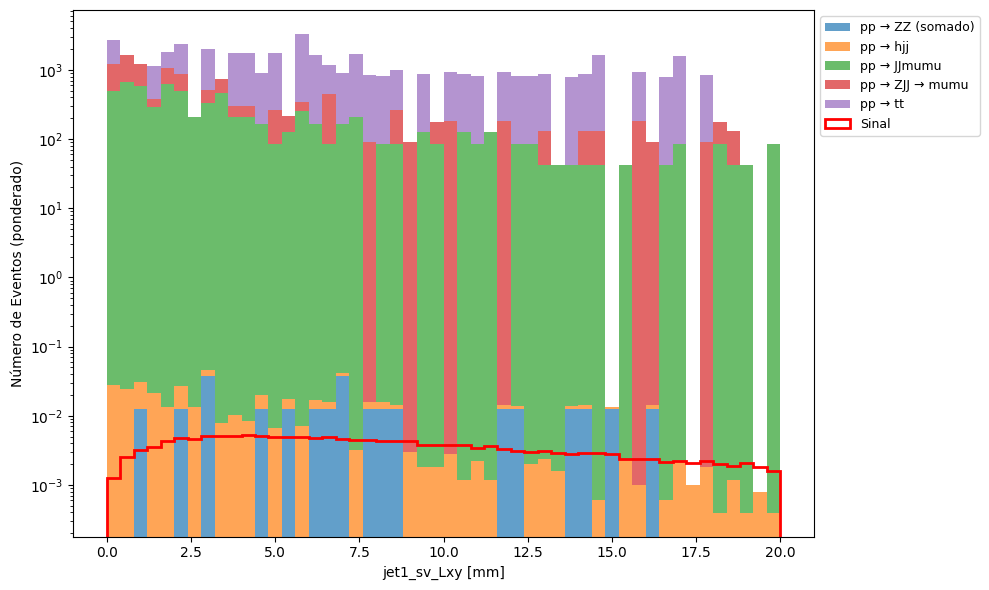

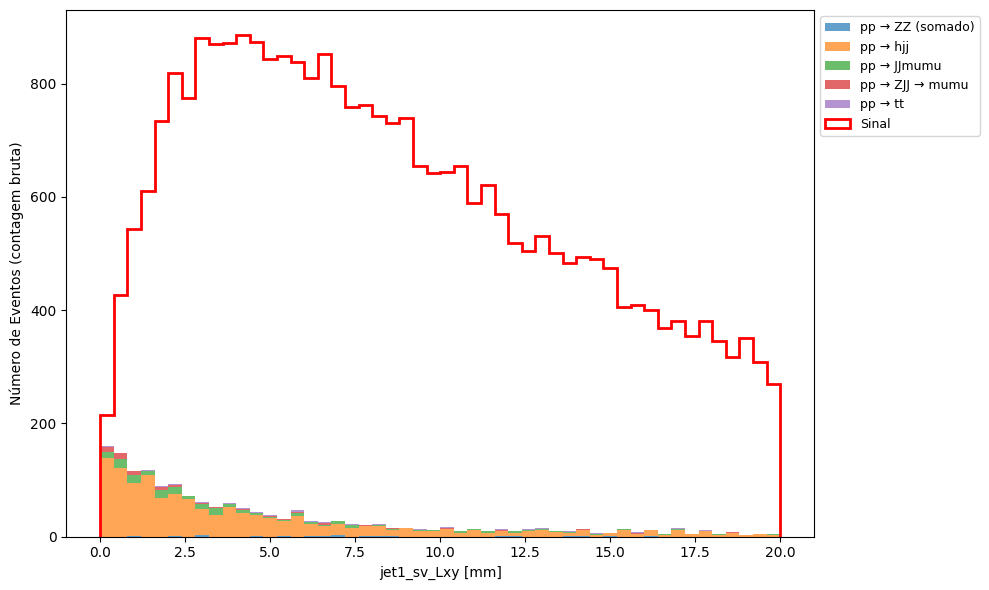

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_raw_v5_sv_weighted.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_Lxy'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_Lxy'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_Lxy'], bins=50, range=(0.001, 20),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001,20),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_Lxy'], bins=50, range=(0.001, 20),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


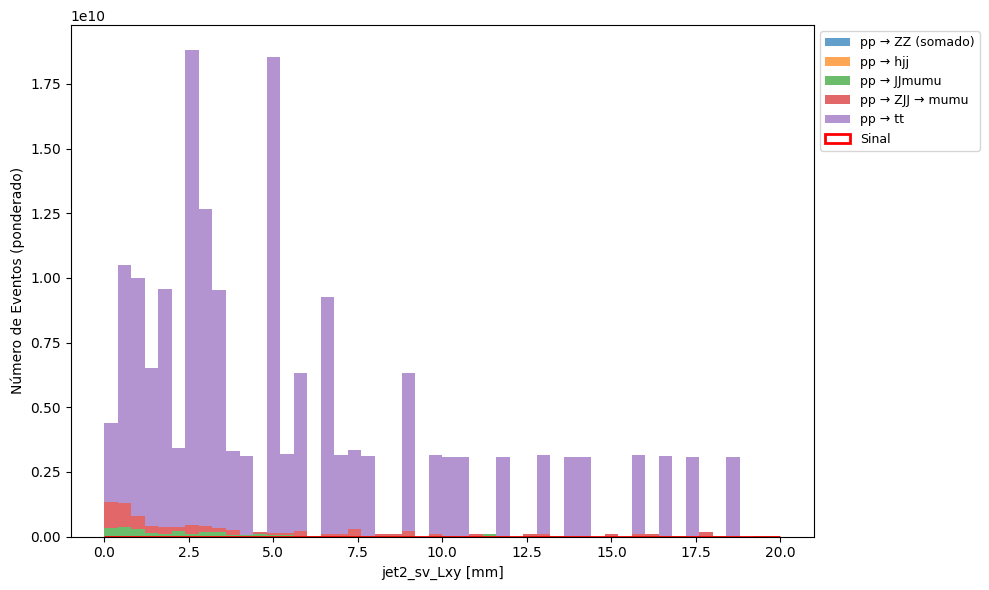

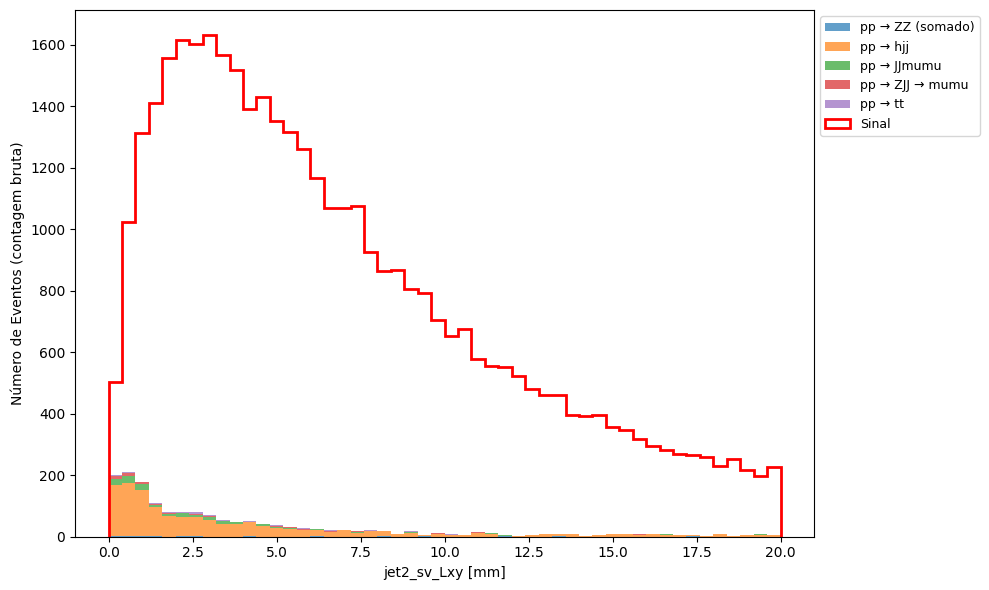

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_normalized_v5.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet2_sv_Lxy'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_Lxy'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_Lxy'], bins=50, range=(0.001, 20),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_Lxy'], bins=50, range=(0.001, 20),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


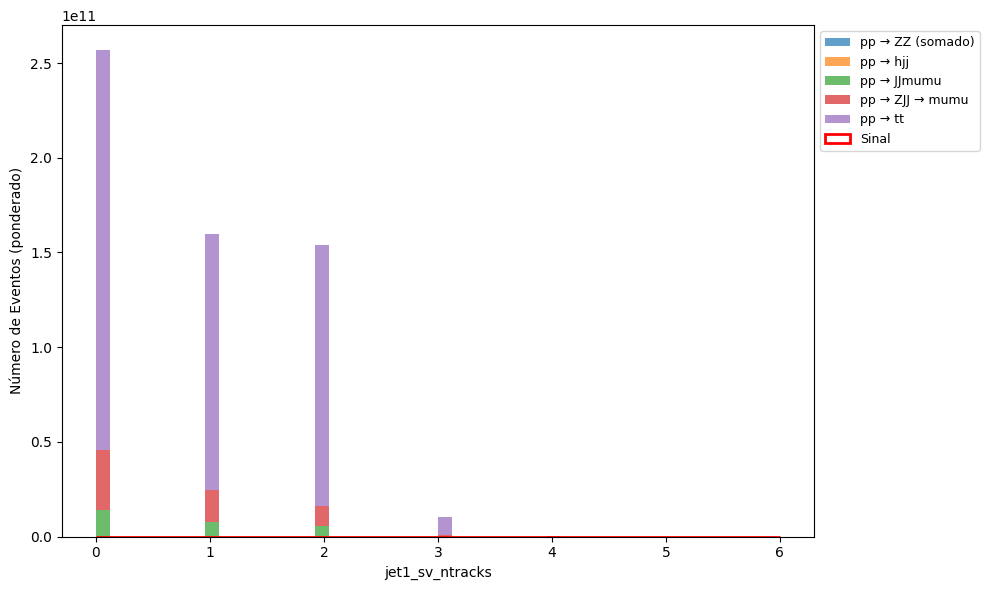

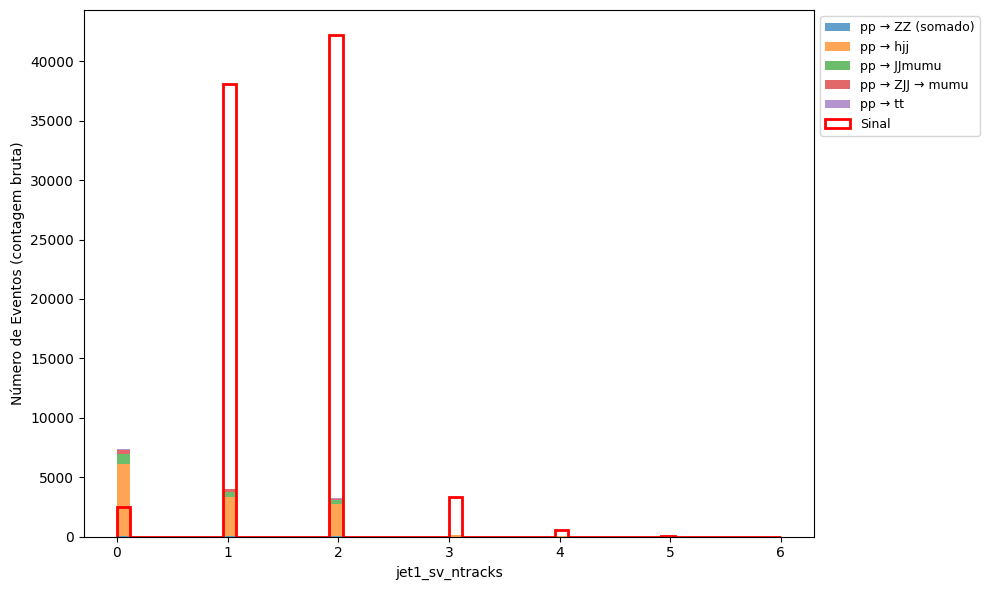

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_normalized_v5.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_ntracks'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_ntracks'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_ntracks'], bins=50, range=(0, 6),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_ntracks')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_ntracks'], bins=50, range=(0, 6),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_ntracks')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


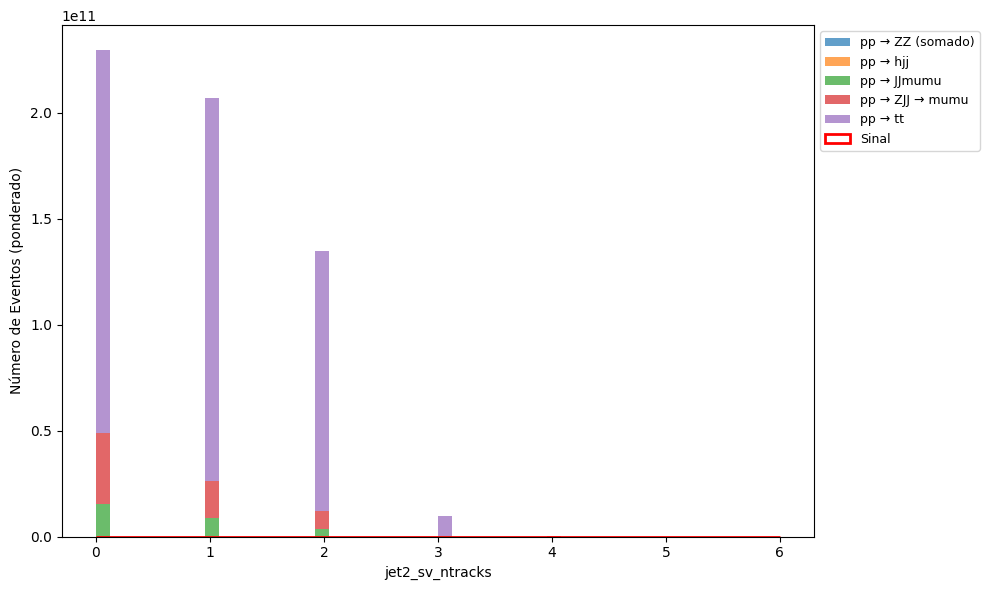

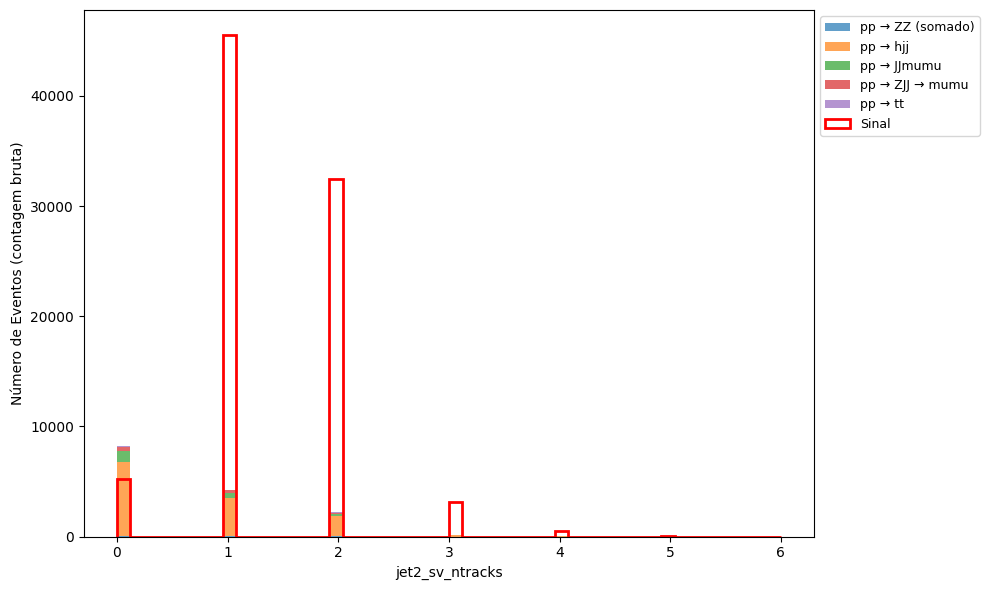

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/lphelipe/Cuts_code/resultados_csv/all_events_normalized_v5.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_ntracks'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_ntracks'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_ntracks'], bins=50, range=(0, 6),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_ntracks')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_ntracks'], bins=50, range=(0, 6),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_ntracks')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
import pyhepmc as hep
import pandas as pd
import fastjet as fj
import numpy as np
import os
import gc
import psutil

# ---------------- Configurações ----------------
max_events = 1000000
chunk_size = 500

output_dir = "resultados_csv"
os.makedirs(output_dir, exist_ok=True)

sinal_files = [f'/home/lphelipe/Resultados/v3/pp_hh_{i}.hepmc' for i in range(1, 11)]
background_files = [
    '/home/lphelipe/Resultados/v3/pp_zz_1.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_2.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_3.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_4.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_5.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_6.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_7.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_8.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_9.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zz_10.hepmc',
    '/home/lphelipe/Resultados/v3/pp_hjj_2mu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jj.hepmc',
    '/home/lphelipe/Resultados/v3/pp_jjmumu.hepmc',
    '/home/lphelipe/Resultados/v3/pp_tt.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2b.hepmc',
    '/home/lphelipe/Resultados/v3/pp_zjj_2mu.hepmc'
]

# ---------------- Funções utilitárias ----------------
def memory_usage_gb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1e9

def extract_cross_section(hepmc_file):
    with open(hepmc_file, 'r') as f:
        for line in f:
            if line.startswith('C'):
                try:
                    return float(line.split()[2])
                except:
                    return 0.0
    return 0.0

def remove_muons(particles):
    return [p for p in particles if abs(p.pid) != 13]

def find_opposite_charge_muons(particles):
    muons = [p for p in particles if abs(p.pid) == 13 and p.momentum.pt() > 20.0 and abs(p.momentum.eta()) < 2.5]
    muons_sorted = sorted(muons, key=lambda m: m.momentum.pt(), reverse=True)
    pairs = []
    used_indices = set()
    for i in range(len(muons_sorted)):
        if i in used_indices:
            continue
        for j in range(i+1, len(muons_sorted)):
            if j in used_indices:
                continue
            if muons_sorted[i].pid == -muons_sorted[j].pid:
                pairs.append((muons_sorted[i], muons_sorted[j]))
                used_indices.update([i, j])
                break
    return pairs

def invariant_mass(j1, j2):
    E = j1.e() + j2.e()
    px = j1.px() + j2.px()
    py = j1.py() + j2.py()
    pz = j1.pz() + j2.pz()
    m2 = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(m2) if m2 > 0 else 0.0

def delta_r(j1, j2):
    dphi = j1.phi() - j2.phi()
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    deta = j1.eta() - j2.eta()
    return np.sqrt(dphi**2 + deta**2)

# ---------------- Secondary Vertex b-tagger (realista) ----------------
def is_b_tagged_secondary_vertex_realistic(jet, event_particles, jet_cone=0.4):

    jet_eta = jet.eta()
    jet_phi = jet.phi()

    jet_tracks = []
    for p in event_particles:
        if getattr(p, "status", None) != 1:
            continue
        if p.production_vertex is None:
            continue
        p_eta = p.momentum.eta()
        p_phi = p.momentum.phi()

        dphi = jet_phi - p_phi
        dphi = (dphi + np.pi) % (2*np.pi) - np.pi
        deta = jet_eta - p_eta
        dR = np.sqrt(dphi*dphi + deta*deta)

        if dR < jet_cone:
            jet_tracks.append(p)

    if len(jet_tracks) < 2:
        return False, 0.0, 0, 0.0

    vertices = {}
    for trk in jet_tracks:
        vtx = trk.production_vertex
        v_id = id(vtx)
        if v_id not in vertices:
            vertices[v_id] = {"vtx_obj": vtx, "tracks": []}
        vertices[v_id]["tracks"].append(trk)

    secondary_candidates = []
    for v_id, info in vertices.items():
        v = info["vtx_obj"]
        x = getattr(v.position, "x", 0.0)
        y = getattr(v.position, "y", 0.0)
        Lxy = np.sqrt(x**2 + y**2)

        if Lxy < 0.1:
            continue

        E = px = py = pz = 0.0
        for trk in info["tracks"]:
            E += trk.momentum.e
            px += trk.momentum.x
            py += trk.momentum.y
            pz += trk.momentum.z

        mass2 = E**2 - (px**2 + py**2 + pz**2)
        mass = np.sqrt(mass2) if mass2 > 0 else 0.0

        secondary_candidates.append({
            "Lxy": Lxy,
            "ntracks": len(info["tracks"]),
            "mass": mass
        })

    if not secondary_candidates:
        return False, 0.0, 0, 0.0

    sv = max(secondary_candidates, key=lambda x: x["Lxy"])

    is_b = (sv["Lxy"] > 0.5 and sv["ntracks"] >= 2 and sv["mass"] > 1.0)

    return is_b, sv["Lxy"], sv["ntracks"], sv["mass"]

# ---------------- Leitura dos chunks ----------------
def read_hepmc_file_in_chunks_with_weights(hepmc_file, max_events=max_events):
    events = []
    weights = []
    filename = os.path.basename(hepmc_file)

    with hep.open(hepmc_file) as f:
        for i, event in enumerate(f):
            if i >= max_events:
                break

            events.append(event)
            w = event.weights[-1] if getattr(event, "weights", None) and len(event.weights) > 0 else 1.0
            weights.append(w)

            # ---- PRINT DE PROGRESSO ----
            if (i + 1) % chunk_size == 0:
                print(f"{i+1} eventos lidos do arquivo {filename} / mem: {memory_usage_gb():.2f} Gb")

                yield events, np.array(weights)
                events = []
                weights = []
                gc.collect()

        # Último chunk
        if events:
            print(f"{i+1} eventos lidos do arquivo {filename} (último chunk) / mem: {memory_usage_gb():.2f} Gb")
            yield events, np.array(weights)

# ---------------- Extração do evento ----------------
def extract_event_info(events, weights=None, cross_section=0.0):

    data = []

    for i, event in enumerate(events):

        particles = [p for p in event.particles if getattr(p, "status", None) == 1 and p.momentum.pt() > 2.0]

        muon_pairs = find_opposite_charge_muons(particles)
        if not muon_pairs:
            continue

        mu1, mu2 = muon_pairs[0]

        m1 = fj.PseudoJet(mu1.momentum.x, mu1.momentum.y, mu1.momentum.z, mu1.momentum.e)
        m2 = fj.PseudoJet(mu2.momentum.x, mu2.momentum.y, mu2.momentum.z, mu2.momentum.e)

        inv_mass_muons = invariant_mass(m1, m2)
        if not (100 < inv_mass_muons < 150):
            continue

        particles_no_muons = remove_muons(particles)

        fj_particles = [
            fj.PseudoJet(p.momentum.x, p.momentum.y, p.momentum.z, p.momentum.e)
            for p in particles_no_muons
        ]

        jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
        cs = fj.ClusterSequence(fj_particles, jet_def)
        jets = [j for j in cs.inclusive_jets(30.0) if abs(j.eta()) < 4.5]

        if len(jets) < 2:
            continue

        jet1, jet2 = sorted(jets, key=lambda j: j.pt(), reverse=True)[:2]

        dijet_mass = invariant_mass(jet1, jet2)
        if not (100 <= dijet_mass <= 125):
            continue

        # -------- b-tag realista --------
        is_b1, Lxy1, ntrk1, mass1 = is_b_tagged_secondary_vertex_realistic(jet1, particles_no_muons)
        is_b2, Lxy2, ntrk2, mass2 = is_b_tagged_secondary_vertex_realistic(jet2, particles_no_muons)

        # >> NOVO CORTE REALISTA <<
        jet1_pass = (Lxy1 > 0.5) and (ntrk1 >= 2) and (mass1 > 1.0)
        jet2_pass = (Lxy2 > 0.5) and (ntrk2 >= 2) and (mass2 > 1.0)

        if not (jet1_pass or jet2_pass):
            continue

        dihiggs_E = m1.e() + m2.e() + jet1.e() + jet2.e()
        dihiggs_px = m1.px() + m2.px() + jet1.px() + jet2.px()
        dihiggs_py = m1.py() + m2.py() + jet1.py() + jet2.py()
        dihiggs_pz = m1.pz() + m2.pz() + jet1.pz() + jet2.pz()
        dihiggs_mass = np.sqrt(max(dihiggs_E**2 - (dihiggs_px**2 + dihiggs_py**2 + dihiggs_pz**2), 0))

        event_info = {
            'muon_mass': inv_mass_muons,
            'muon1_pt': m1.pt(),
            'muon2_pt': m2.pt(),
            'muon1_eta': m1.eta(),
            'muon2_eta': m2.eta(),
            'dijet_mass': dijet_mass,
            'dihiggs_mass': dihiggs_mass,
            'jet1_pt': jet1.pt(),
            'jet2_pt': jet2.pt(),
            'jet1_eta': jet1.eta(),
            'jet2_eta': jet2.eta(),

            # --- variáveis de b-tag ---
            'jet1_is_b_tagged': is_b1,
            'jet2_is_b_tagged': is_b2,
            'jet1_sv_Lxy': Lxy1,
            'jet2_sv_Lxy': Lxy2,
            'jet1_sv_ntracks': ntrk1,
            'jet2_sv_ntracks': ntrk2,
            'jet1_sv_mass': mass1,
            'jet2_sv_mass': mass2,

            'weight': weights[i] if weights is not None and i < len(weights) else 1.0,
            'cross_section_pb': cross_section
        }

        data.append(event_info)

    return pd.DataFrame(data)

# ---------------- Processamento ----------------
def process_files(file_list, label):
    all_dfs = []
    for f in file_list:
        cs = extract_cross_section(f)
        for chunk, weights in read_hepmc_file_in_chunks_with_weights(f):
            df_chunk = extract_event_info(chunk, weights, cross_section=cs)
            if df_chunk.empty:
                continue
            df_chunk['label'] = label
            all_dfs.append(df_chunk)

    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        return pd.DataFrame()

# ---------------- Rodar a análise ----------------
if __name__ == "__main__":

    signal_df = process_files(sinal_files, label=1)
    signal_df.to_csv(os.path.join(output_dir, "signal_raw_v6_sv.csv"), index=False)

    background_df = process_files(background_files, label=0)
    background_df.to_csv(os.path.join(output_dir, "background_raw_v6_sv.csv"), index=False)

    combined_df = pd.concat([signal_df, background_df], ignore_index=True) \
                    if (not signal_df.empty or not background_df.empty) else pd.DataFrame()

    if not combined_df.empty:
        combined_df.to_csv(os.path.join(output_dir, "all_events_raw_v6_sv.csv"), index=False)
        print(f">> Arquivos salvos em {output_dir}")
    else:
        print(">> Nenhum evento selecionado.")

    metadata = []
    for f in sinal_files + background_files:
        metadata.append({"file": os.path.basename(f), "cross_section_pb": extract_cross_section(f)})

    pd.DataFrame(metadata).to_csv(os.path.join(output_dir, "cross_sections_v6_sv.csv"), index=False)
    print(f">> Cross sections salvas.")


500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.15 Gb
1000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.78 Gb
1500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.78 Gb
2000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.84 Gb
2500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.84 Gb
3000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
3500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
4000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
4500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
5000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
5500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
6000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
6500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.86 Gb
7000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.87 Gb
7500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.87 Gb
8000 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.87 Gb
8500 eventos lidos do arquivo pp_hh_1.hepmc / mem: 2.87 G